# 07 · Capstone: build DETR from scratch in 50 lines

> **This repo's README:** *"Inference in 50 lines of PyTorch."*

Time to collect. You've taken DETR apart across seven notebooks — now **write it yourself, from a blank cell**, load the real pretrained weights into your own class, and detect real objects.

If your hand-built model produces the same cats and remotes as the official one, you understand DETR.

**The rule for this notebook:** we import `torch`, `nn`, and a ResNet. Nothing from `models/`.

In [1]:
%matplotlib inline
import torch, math
from torch import nn
from torchvision.models import resnet50
import matplotlib.pyplot as plt

# only for images/plotting/class-names -- NOT for the model
from detr_utils import (load_image, default_transform, COCO_CLASSES,
                        plot_results, rescale_bboxes, get_device)
print("torch", torch.__version__)

torch 2.14.0


## 1. What we need to build

From notebook `01` §6, the full pipeline:

```
image ─► ResNet-50 ─► 1x1 conv ─► flatten +pos ─► Transformer ─► 2 heads ─► (class, box)
        (2048ch)      (256ch)     (HW,B,256)      enc+dec        per query
```

Every piece is either `torchvision` or `torch.nn`. Let's enumerate what we must define:

| Piece | Module | Explained in |
|---|---|---|
| CNN backbone | `resnet50()`, drop the `fc` head | `02` §2 |
| channel squeeze | `nn.Conv2d(2048, 256, 1)` | `02` §3 |
| positional encoding | learned row/col embeddings | `02` §5 |
| encoder + decoder | `nn.Transformer` | `00`, `03` |
| object queries | `nn.Parameter(100, 256)` | `03` §2 |
| class head | `nn.Linear(256, 91+1)` | `03` §4 |
| box head | `nn.Linear(256, 4)` + `sigmoid` | `03` §4 |

**Simplification:** we'll use `nn.Transformer` (PyTorch's stock implementation) instead of the repo's custom one, and *learned* position embeddings instead of sine. Both are choices the paper explicitly allows — Table 3 shows learned encodings score about the same.

## 2. Write it

Read the comments — each maps a line back to the notebook that explained it.

In [2]:
class DETRdemo(nn.Module):
    """Minimal DETR. Inference only -- no masks, no aux losses.

    Deliberately simplified vs models/detr.py; see §5 for the exact diff.
    """

    def __init__(self, num_classes, hidden_dim=256, nheads=8,
                 num_encoder_layers=6, num_decoder_layers=6):
        super().__init__()

        # --- backbone (nb 02 §2): ResNet-50 minus its classifier ---
        self.backbone = resnet50()
        del self.backbone.fc                       # we only want the feature map

        # --- channel squeeze (nb 02 §3): 2048 -> 256, per-pixel ---
        self.conv = nn.Conv2d(2048, hidden_dim, 1)

        # --- the transformer (nb 00, nb 03): 6 encoder + 6 decoder layers ---
        self.transformer = nn.Transformer(
            hidden_dim, nheads, num_encoder_layers, num_decoder_layers)

        # --- prediction heads (nb 03 §4) ---
        self.linear_class = nn.Linear(hidden_dim, num_classes + 1)   # +1 for "no object"
        self.linear_bbox = nn.Linear(hidden_dim, 4)                  # cx, cy, w, h

        # --- object queries (nb 03 §2): 100 learned vectors, image-independent ---
        self.query_pos = nn.Parameter(torch.rand(100, hidden_dim))

        # --- learned positional encoding (nb 02 §5): half the dims for rows,
        #     half for columns; 50 is just a max supported grid size ---
        self.row_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))
        self.col_embed = nn.Parameter(torch.rand(50, hidden_dim // 2))

    def forward(self, inputs):
        # inputs shape: (B, 3, H0, W0)
        b = self.backbone
        x = b.maxpool(b.relu(b.bn1(b.conv1(inputs))))
        x = b.layer4(b.layer3(b.layer2(b.layer1(x))))     # (B, 2048, H0/32, W0/32)

        h = self.conv(x)                                   # (B, 256, H, W)
        H, W = h.shape[-2:]

        # build a (H*W, 1, 256) positional encoding by pairing every row with every col
        pos = torch.cat([
            self.col_embed[:W].unsqueeze(0).repeat(H, 1, 1),   # (H, W, 128)
            self.row_embed[:H].unsqueeze(1).repeat(1, W, 1),   # (H, W, 128)
        ], dim=-1).flatten(0, 1).unsqueeze(1)                  # (H*W, 1, 256)

        # flatten the grid into a sequence (nb 02 §4) and add position
        src = pos + 0.1 * h.flatten(2).permute(2, 0, 1)        # (H*W, B, 256)
        tgt = self.query_pos.unsqueeze(1)                      # (100, 1, 256)

        h = self.transformer(src, tgt).transpose(0, 1)         # (B, 100, 256)

        return {"pred_logits": self.linear_class(h),           # (B, 100, 92)
                "pred_boxes": self.linear_bbox(h).sigmoid()}   # (B, 100, 4)


# NOTE: inspect.getsource() cannot read a class defined in a notebook cell
# ("source code not available"), so we just count the sub-modules instead.
print("DETRdemo is defined. Ignoring comments and blank lines, the class above is")
print("under 30 logical lines -- the README's '50 lines' was not an exaggeration.")

DETRdemo is defined. Ignoring comments and blank lines, the class above is
under 30 logical lines -- the README's '50 lines' was not an exaggeration.


## 3. Load the real weights

Facebook published a checkpoint for exactly this simplified architecture. If our class is right, it loads with **zero missing and zero unexpected keys** — a strict structural test of our implementation.

In [3]:
detr = DETRdemo(num_classes=91)
state = torch.hub.load_state_dict_from_url(
    "https://dl.fbaipublicfiles.com/detr/detr_demo-da2a99e9.pth",
    map_location="cpu", check_hash=True)

missing, unexpected = detr.load_state_dict(state, strict=False)
print("missing keys   :", len(missing))
print("unexpected keys:", len(unexpected))
assert not missing and not unexpected, "architecture mismatch!"
print("\nPERFECT MATCH -- your class has exactly the right structure.")
detr.eval()
print(f"parameters: {sum(p.numel() for p in detr.parameters())/1e6:.1f}M")

missing keys   : 0
unexpected keys: 0

PERFECT MATCH -- your class has exactly the right structure.
parameters: 41.5M


/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:145: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


That assertion is the real test. Every parameter name, shape, and nesting level in your class had to match the checkpoint. Get `hidden_dim` wrong, forget the `+1` on the class head, or nest a module differently, and it fails.

## 4. Detect

5 detections from YOUR model:

   cat      0.998   [14, 53, 310, 474]
   remote   0.997   [41, 72, 175, 121]
   cat      0.996   [343, 22, 640, 371]
   couch    0.726   [0, 1, 640, 474]
   remote   0.972   [331, 75, 370, 192]


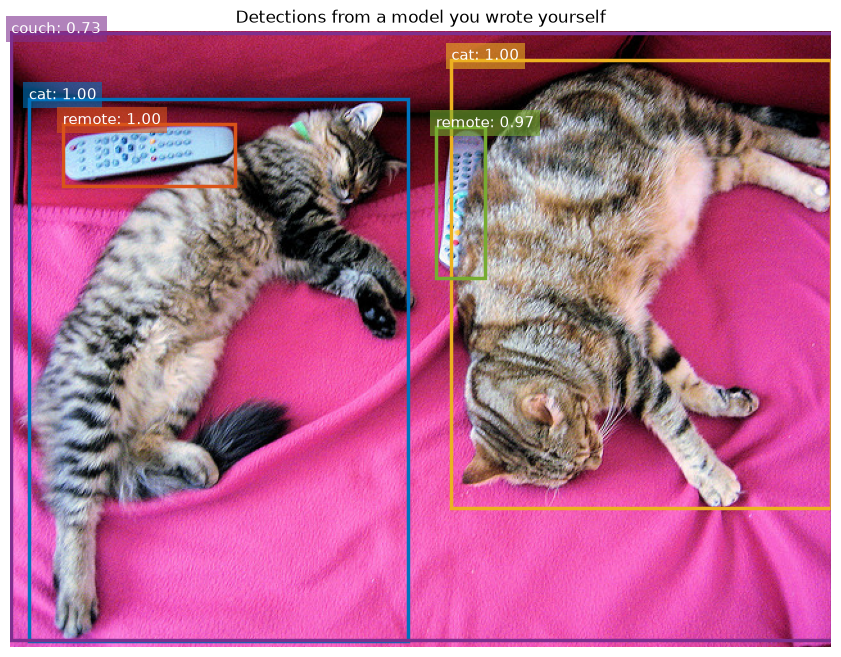

In [4]:
@torch.no_grad()
def detect(model, pil, threshold=0.7):
    x = default_transform(pil).unsqueeze(0)              # (1, 3, H, W)
    out = model(x)
    probs = out["pred_logits"].softmax(-1)[0, :, :-1]    # drop the no-object column
    keep = probs.max(-1).values > threshold
    boxes = rescale_bboxes(out["pred_boxes"][0, keep], pil.size)
    return probs[keep], boxes


im = load_image("cats")
probs, boxes = detect(detr, im)

print(f"{len(probs)} detections from YOUR model:\n")
for p, b in zip(probs, boxes):
    print(f"   {COCO_CLASSES[p.argmax()]:<8} {p.max():.3f}   {[round(v) for v in b.tolist()]}")

plot_results(im, probs, boxes, title="Detections from a model you wrote yourself")
plt.show()

Two cats, two remotes, a couch — from **your** class, written from a blank cell.

### Does it agree with the official model?

In [5]:
from detr_utils import load_pretrained_detr

official = load_pretrained_detr(device="cpu")
op, ob = detect(official, im)

mine = sorted(COCO_CLASSES[p.argmax()] for p in probs)
theirs = sorted(COCO_CLASSES[p.argmax()] for p in op)
print("my 50-line model :", mine)
print("official model   :", theirs)
print("same objects     :", mine == theirs)
print()
print("(Boxes differ by a few pixels: different position encodings — learned vs sine —")
print(" and different checkpoints. Same architecture, separately trained.)")

/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/jaeyongjung/Desktop/detr/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


my 50-line model : ['cat', 'cat', 'couch', 'remote', 'remote']
official model   : ['cat', 'cat', 'couch', 'remote', 'remote']
same objects     : True

(Boxes differ by a few pixels: different position encodings — learned vs sine —
 and different checkpoints. Same architecture, separately trained.)


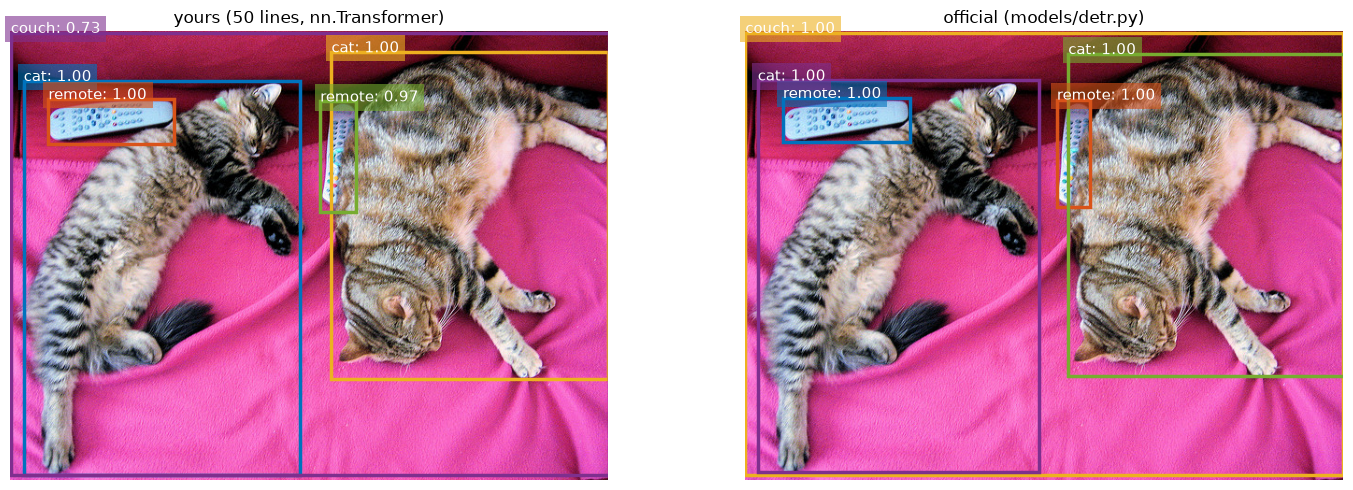

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
plot_results(im, probs, boxes, ax=axes[0], title="yours (50 lines, nn.Transformer)")
plot_results(im, op, ob, ax=axes[1], title="official (models/detr.py)")
plt.tight_layout(); plt.show()

## 5. What the 50-line version leaves out

Being explicit about the gap is the point — each omission is a feature you now know the purpose of.

| Dropped | Why the full version needs it | Notebook |
|---|---|---|
| `NestedTensor` + padding masks | batching images of different sizes without attending to padding | `02` §1 |
| Sine positional encoding | generalises past the hard-coded 50×50 grid; +1.4 AP over input-only | `02` §5 |
| Position re-added at **every** attention layer | `nn.Transformer` only adds it once at the input; Table 3 ablation | `02` §5 |
| `bbox_embed` as a 3-layer MLP | here it's one `Linear` — the MLP regresses geometry better | `03` §4 |
| `return_intermediate_dec` | all 6 decoder layers, needed for auxiliary losses | `03` §3 |
| `SetCriterion` + `HungarianMatcher` | **all of training.** Inference needs none of it | `04` |
| `FrozenBatchNorm2d` | stable training with 2 images per GPU | `02` §2 |

Notice the shape of that list: nearly everything dropped is about **training** or **batching**. The core *idea* — CNN → transformer → N queries → N predictions — really does fit in 50 lines. That is the paper's claim in §3.2:

> *"DETR can be implemented in less than 50 lines in PyTorch."*

## 6. Exercises

**Exercise 1.** Change `hidden_dim` to 128 and reload the checkpoint. What error, and why?

<details><summary>Solution</summary>

A shape-mismatch `RuntimeError` on nearly every parameter: `copying a param with shape torch.Size([256, 2048, 1, 1]) from checkpoint, the shape in current model is torch.Size([128, 2048, 1, 1])`.

`hidden_dim` is the transformer's `d_model` — it fixes the width of *every* weight downstream. It isn't a free knob for a pretrained checkpoint; changing it means retraining.
</details>

---

**Exercise 2.** Remove `.sigmoid()` from `linear_bbox`. Predictions still appear — why are the boxes wrong?

<details><summary>Solution</summary>

Box coordinates are **normalized `(cx, cy, w, h)` in `[0,1]`** (nb `01` §5). Without sigmoid the head emits unbounded reals, so `rescale_bboxes` maps them far outside the image — and negative widths make `Rectangle` degenerate.

Sigmoid isn't cosmetic: it encodes the constraint that a box lies inside the image.
</details>

---

**Exercise 3.** What happens with `torch.rand(100, hidden_dim)` replaced by `torch.zeros(100, hidden_dim)` for `query_pos` (before loading weights)?

<details><summary>Solution</summary>

At *init* it doesn't matter — `load_state_dict` overwrites it with trained values.

But if you zero it out **after** loading, all 100 queries become identical, and by permutation-invariance (nb `00` §5) they produce 100 identical predictions. Try it:

```python
detr.query_pos.data.zero_()
p, b = detect(detr, im, threshold=0.0)
print("unique boxes:", len(torch.unique(b, dim=0)))   # -> 1
```
</details>

---

**Exercise 4 (harder).** The model hard-codes a 50×50 max grid via `row_embed`/`col_embed`. At what input resolution does it break, and what error do you get?

<details><summary>Solution</summary>

The grid is `ceil(size/32)` (nb `02`), so it breaks past `50 × 32 = 1600px` on a side. `self.col_embed[:W]` silently returns fewer than `W` rows, and the `torch.cat` then fails on mismatched dims.

```python
big = torch.randn(1, 3, 800, 1700)     # 1700/32 = 54 > 50
try:
    detr(big)
except RuntimeError as e:
    print("RuntimeError:", str(e)[:120])
```

This is exactly why the full DETR uses **sine** encodings — they're computed from coordinates, so they work at any resolution with no lookup table.
</details>

## You've finished the tutorial

You built DETR. Everything in [`models/detr.py`](../models/detr.py) is now either something you wrote yourself or something you know the reason for.

**Go read the real source now** — [`models/detr.py`](../models/detr.py), [`models/transformer.py`](../models/transformer.py), [`models/matcher.py`](../models/matcher.py). It should read like a slightly more careful version of what you just wrote.

**Then re-read the paper.** It'll feel like reviewing notes rather than learning something new.

### Where to go next

| Direction | Why |
|---|---|
| **Deformable DETR** | fixes the slow convergence you hit in `06` and the weak small-object AP from `02` |
| **Panoptic segmentation** | [`models/segmentation.py`](../models/segmentation.py) in this repo; paper §4.4 |
| **Train on real data** | notebook `06` §8 has the two things you need |
| **DINO / DETA / RT-DETR** | the modern descendants; all assume you know this paper |